In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [3]:
%matplotlib widget
plt.close('all')

In [4]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'old', 'lampadina_test_final', 'lampadina3_test', '…

In [5]:
images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)
image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

In [6]:
print(images[0].dtype)
print(images[0].shape)

images_arr = np.array(images)

print(images_arr.shape)



uint8
(480, 640)
(2765, 480, 640)


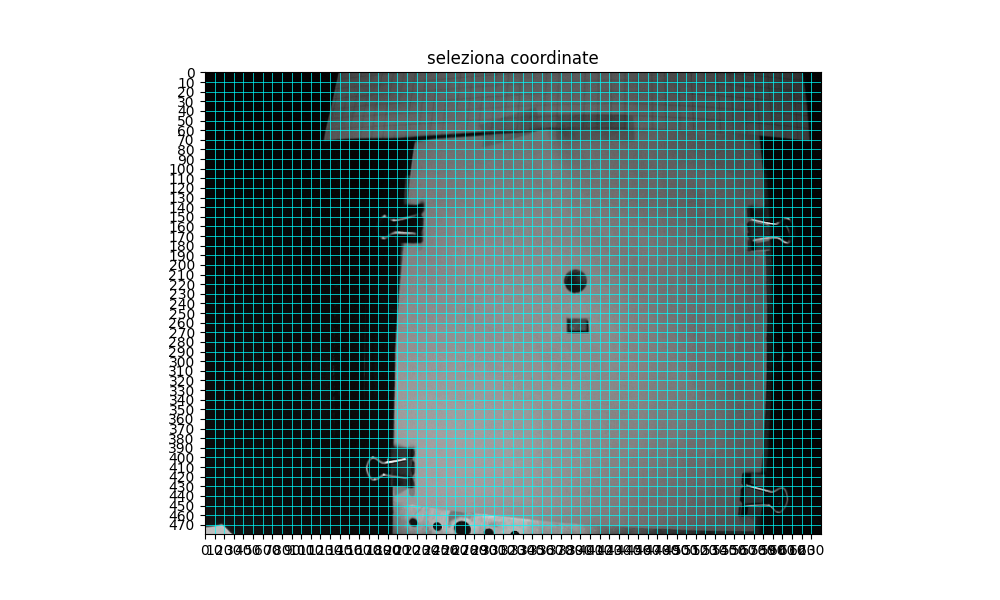

In [10]:
image_sample = images[0]

plt.figure(figsize=(10,6))
plt.imshow(image_sample, cmap='gray')

plt.xticks(np.arange(0, image_sample.shape[1], 10))
plt.yticks(np.arange(0, image_sample.shape[0], 10))
plt.grid(color='cyan', linestyle='-', linewidth=0.5)
plt.title("seleziona coordinate")
plt.show()

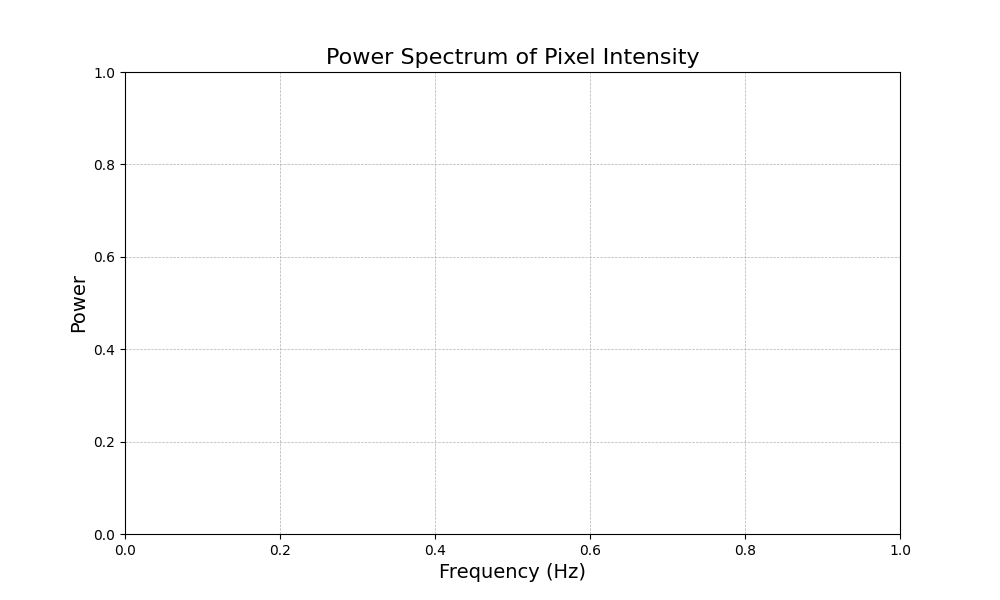

In [ ]:
intensita = [images_arr[i, 245, 474] for i in range(len(images_arr))]

fft = np.fft.rfft(intensita)
powerspectrum = np.abs(fft)**2

frequenze = np.fft.rfftfreq(len(intensita), d=np.mean(np.diff(image_seconds)))

In [ ]:
plt.figure(figsize=(10,6))

for i in range(len(powerspectrum)):
    plt.loglog(frequenze, powerspectrum[i], alpha=0.2)

In [7]:
#images_arr = np.array(images)

step = 10

images_stepped = images_arr[:, ::step, ::step]
images_final = images_stepped[2700:2765]

intensita_pixel = images_final.reshape(images_final.shape[0], -1).T
#questa matrice ha forma (num_pixel, num_frames), dove ogni riga contiene l'intensità di un pixel attraverso tutti i frames

fft_pixel = np.fft.rfft(intensita_pixel, axis=1)
powerspectrum = np.abs(fft_pixel)**2

frequenze = np.fft.rfftfreq(intensita_pixel.shape[1], d=np.mean(np.diff(image_seconds)))
# d è il tempo di campionamento

In [8]:
print(images_final.shape)
print(powerspectrum.shape)
print(frequenze.shape)

(65, 48, 64)
(3072, 33)
(33,)


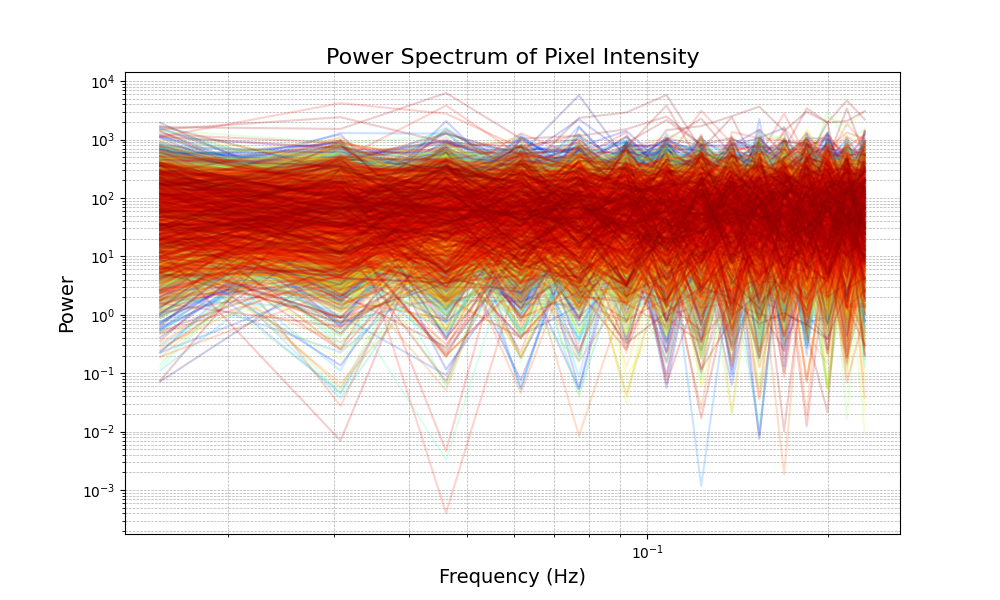

In [9]:
half_points = len(frequenze) // 2

frequenze = frequenze[1:half_points]
powerspectrum = powerspectrum[:, 1:half_points]

plt.figure(figsize=(10, 6))

colori = plt.cm.jet(np.linspace(0, 1, powerspectrum.shape[0]))

for i in range(powerspectrum.shape[0]):
    plt.loglog(frequenze, powerspectrum[i], alpha=0.2, color=colori[i])
    
plt.title('Power Spectrum of Pixel Intensity', fontsize=16)
plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Power', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()